

The NHS RTT dataset records the month to month metrics for NHS providers in respect of waiting times, including Large Acute Trusts such as Mid South Essex. The dataset establishes a relationship which is described by Watson/Fisher:

In any given month, we expect the size of the waiting list to equal the incomplete pathways from the month before, plus new referrals in the given month, minus the reported completed pathways in the given month.

The authors find that "unreported removals equate to around 3% of the size of the waiting list".

see @fig-polar.

From my analysis of the RTT dataset for 2024, for large acute trusts excluding RAJ, I find a similar number:

In [93]:
#| echo: false

from pathlib import Path

import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy import text, bindparam

from nhs_waiting_lists import (
    __app_name__,
)
from nhs_waiting_lists.constants import proj_db_path, DB_FILE
from nhs_waiting_lists.utils.xdg import XDGBasedir

project_root = Path(XDGBasedir.get_data_dir(__app_name__))

DB_PATH = project_root / proj_db_path / DB_FILE
FILES_DIR = project_root / "files"

engine = create_engine(f"sqlite:///{DB_PATH}")

In [94]:
#| echo: false

# PROVIDER_CODES = ['R0B', 'RAJ', 'RTH', 'RTE', "RTF", "RWF", "RTE", "REF",
# "RWH", "R0B", "RVJ", "RHW", "RDU", "RH8",
#                   "RWY",
#                   "RXC", "RL4", "RDE", "RXK", "RXR", "RJ2", "RN5", "RHU",
#                   "RGN", "RWP", "RWD", "RAJ", 'RTF', 'RXC']
# # PROVIDER_COEDS = ('RAJ', 'RTH', 'RJZ', 'RH5', 'R0B', 'RTF', 'RXC')
# TREATMENT_CODES = (
#     'C_100',
#     'C_101',
#     'C_110',
#     'C_320',
#     'C_330',
#     'C_400',
#     'C_502',
#     'C_301'
# )

# PROVIDER_CODES = ["RTF", "RWF", "RTE", "REF", "RWH",
# "R0B", "RVJ", "RHW",
# "RDU", "RH8", "RWY", "RXC", "RL4", "RDE",
#                   "RXK", "RXR", "RJ2", "RN5",
#                   "RHU", "RGN", "RWP", "RWD", "RAJ"]

PROVIDER_CODES = ["RTF", "RWF", "RTE", "REF", "RWH", "R0B", "RVJ",
                  "RHW", "RDU", "RH8", "RWY", "RXC", "RL4", "RDE",
                  "RXK", "RXR", "RJ2", "RN5", "RHU", "RGN", "RWP",
                  "RWD", "RAJ"]

ALL_TREATMENT_CODES = ("C_100", "C_101", "C_110", "C_120", "C_130",
                       "C_140", "C_150", "C_160", "C_170", "C_300",
                       "C_301", "C_320", "C_330", "C_340", "C_400",
                       "C_410", "C_430", "C_502", "X02", "X03",
                       "X04", "X05", "X06")

TOTAL_ONLY_TREATMENT_CODES = ('C_999',)

# TREATMENT_CODES = ALL_TREATMENT_CODES
TREATMENT_CODES = TOTAL_ONLY_TREATMENT_CODES

#
# provider_code = "RAJ"
# treatment_code = "C_110"

## Retrieve all the provider rtt summary data

In [95]:
#| echo: false
#| output: false

consolidated_query = text("""
                          SELECT i.period,
                                 i.provider,
                                 i.treatment,
                                 i.untreated                                                       AS untreated,
                                 100 *
                                 (CAST(i.untreated as REAL) / (i.incomplete_prev + i.new_periods)) AS untreated_pct,
                                 i.new_periods                                                     AS new_periods,
                                 i.incomplete,
                                 i.incomplete_prev                                                 AS incomplete_prev,
                                 i.treated                                                         AS treated
                          FROM consolidated AS i
                                   JOIN provider AS p ON i.provider = p.provider
                          WHERE i.provider IN :provider_codes
                            AND i.treatment IN :treatment_codes
                            AND i.period >= '2024-01'
                            AND i.period <= '2024-12'
                            AND subtype = 'Acute - Large'
                          ORDER BY i.provider ASC, i.period ASC; \
                          """).bindparams(
    bindparam('provider_codes', expanding=True),
    bindparam('treatment_codes', expanding=True)
)

consolidated_df = pd.read_sql(consolidated_query, engine, params={
    'provider_codes': PROVIDER_CODES,
    'treatment_codes': TREATMENT_CODES}
                              )  # type: ignore[arg-type]

consolidated_df["period"] = pd.to_datetime(consolidated_df["period"], errors="coerce")

# valid = (consolidated_df['incomplete_prev'] > 100) & (consolidated_df['new_periods'] > 30)
# consolidated_df = consolidated_df.loc[valid].copy()

styled_df = consolidated_df.style

styled_df = consolidated_df.style.highlight_max(axis=0)




## Retrieve the "other large acute trusts" data subset


In [96]:
#| echo: false
#| output: false

other_trusts = consolidated_df.query("provider != 'RAJ'")

other_trusts

,period,provider,treatment,untreated,untreated_pct,new_periods,incomplete,incomplete_prev,treated
0,2024-01-01,R0B,C_999,-2871,-3.617600,18812,60893,60550,15598
1,2024-02-01,R0B,C_999,-2593,-3.248681,18924,62414,60893,14810
2,2024-03-01,R0B,C_999,-3423,-4.271862,17715,62324,62414,14382
3,2024-04-01,R0B,C_999,-5070,-6.253160,18755,60982,62324,15027
4,2024-05-01,R0B,C_999,-3010,-3.755787,19161,61709,60982,15424
...,...,...,...,...,...,...,...,...,...
271,2024-08-01,RXR,C_999,-5467,-6.402089,13052,69363,72342,10564
272,2024-09-01,RXR,C_999,-3592,-4.319852,13788,68142,69363,11417
273,2024-10-01,RXR,C_999,-5202,-6.221223,15475,66279,68142,12136
274,2024-11-01,RXR,C_999,-3425,-4.262601,14071,65265,66279,11660


In [97]:
#| echo: false
#| output: false

print(other_trusts.dtypes)

other_result: pd.DataFrame = other_trusts.groupby(['period'])[
    ['incomplete_prev', 'new_periods', 'treated', 'untreated', "incomplete"]].sum().reset_index()

other_result["total_pathways"] = other_result["incomplete_prev"] + other_result["new_periods"]

other_result["unexplained"] = other_result["incomplete"] - (
        other_result["incomplete_prev"] + other_result["new_periods"] - other_result["treated"])

other_result["unexplained_pct"] = other_result["untreated"] / other_result["total_pathways"]

other_result["expected_pathways"] = other_result["incomplete_prev"] + other_result["new_periods"] - other_result[
    "treated"]

other_result["actual_pathways"] = other_result["incomplete"]

other_result[["period", "actual_pathways", "expected_pathways", "unexplained", "total_pathways", "unexplained_pct"]]


period             datetime64[ns]
provider                   object
treatment                  object
untreated                   int64
untreated_pct             float64
new_periods                 int64
incomplete                  int64
incomplete_prev             int64
treated                     int64
dtype: object


,period,actual_pathways,expected_pathways,unexplained,total_pathways,unexplained_pct
0,2024-01-01,1355909,1406947,-51038,1675204,-0.030467
1,2024-02-01,1356430,1406080,-49650,1659809,-0.029913
2,2024-03-01,1355242,1401626,-46384,1649376,-0.028122
3,2024-04-01,1363802,1408342,-44540,1662020,-0.026799
4,2024-05-01,1371241,1417668,-46427,1677729,-0.027673
5,2024-06-01,1377303,1419740,-42437,1670751,-0.025400
6,2024-07-01,1372476,1426756,-54280,1704923,-0.031837
7,2024-08-01,1368441,1415013,-46572,1658678,-0.028078
8,2024-09-01,1364129,1406322,-42193,1671750,-0.025239
9,2024-10-01,1359924,1411835,-51911,1700623,-0.030525


In [98]:
#| echo: false
#| output: false

"{:.3%}".format(
    other_trusts['untreated'].sum() / (other_trusts['incomplete_prev'].sum() + other_trusts['new_periods'].sum()))


'-2.829%'

In [99]:
#| echo: false
#| output: true

df = other_result

# Calculate summary row
summary = pd.DataFrame({
    'period': ['TOTAL/AVG'],
    'actual_pathways': [df['actual_pathways'].mean()],
    'expected_pathways': [df['expected_pathways'].mean()],
    'unexplained': [df['unexplained'].sum()],
    'total_pathways': [df['total_pathways'].mean()],
    'unexplained_pct': [df['unexplained'].sum() / df['total_pathways'].sum()]
})

# Append summary
display_df = pd.concat(
    [df[["period", "actual_pathways", "expected_pathways", "unexplained", "total_pathways", "unexplained_pct"]],
     summary], ignore_index=True)

display_df = display_df.rename(columns={
    'actual_pathways': 'Actual<br>Pathways',
    'expected_pathways': 'Expected<br>Pathways',
    'unexplained': 'Unexplained<br>Change',
    'total_pathways': 'Total<br>Pathways',
    'unexplained_pct': 'Unexplained<br>%'
})


# Style it
styled = (display_df
          .style
    .hide(axis='index')
          .format({
    'period': lambda x: x.strftime('%Y-%m') if isinstance(x, pd.Timestamp) else x,
    'Actual<br>Pathways': '{:,.0f}',
    'Expected<br>Pathways': '{:,.0f}',
    'Unexplained<br>Change': '{:,.0f}',
    'Total<br>Pathways': '{:,.0f}',
    'Unexplained<br>%': '{:.2%}',
})
          .map(lambda x: 'font-weight: bold' if x == 'TOTAL/AVG' else '', subset=['period'])
          )

styled


period,ActualPathways,ExpectedPathways,UnexplainedChange,TotalPathways,Unexplained%
2024-01,"1,355,909","1,406,947","-51,038","1,675,204",-3.05%
2024-02,"1,356,430","1,406,080","-49,650","1,659,809",-2.99%
2024-03,"1,355,242","1,401,626","-46,384","1,649,376",-2.81%
2024-04,"1,363,802","1,408,342","-44,540","1,662,020",-2.68%
2024-05,"1,371,241","1,417,668","-46,427","1,677,729",-2.77%
2024-06,"1,377,303","1,419,740","-42,437","1,670,751",-2.54%
2024-07,"1,372,476","1,426,756","-54,280","1,704,923",-3.18%
2024-08,"1,368,441","1,415,013","-46,572","1,658,678",-2.81%
2024-09,"1,364,129","1,406,322","-42,193","1,671,750",-2.52%
2024-10,"1,359,924","1,411,835","-51,911","1,700,623",-3.05%


So we can see from the table, that the acute trusts excluding RAJ, have an unexplained loss of about 2.8% of pathways per month.

In [100]:
#| echo: false
#| output: false

other_result.describe()

,period,incomplete_prev,new_periods,treated,untreated,incomplete,total_pathways,unexplained,unexplained_pct,expected_pathways,actual_pathways
count,12,1.200000e+01,12.000000,12.000000,12.000000,1.200000e+01,1.200000e+01,12.000000,12.000000,1.200000e+01,1.200000e+01
mean,2024-06-16 08:00:00,1.362849e+06,305645.416667,260442.083333,-47207.250000,1.360846e+06,1.668495e+06,-47207.250000,-0.028279,1.408053e+06,1.360846e+06
min,2024-01-01 00:00:00,1.347169e+06,274825.000000,240913.000000,-54280.000000,1.338080e+06,1.621994e+06,-54280.000000,-0.031837,1.381081e+06,1.338080e+06
25%,2024-03-24 06:00:00,1.356300e+06,297869.000000,250195.750000,-49997.000000,1.355742e+06,1.659526e+06,-49997.000000,-0.030051,1.404966e+06,1.355742e+06
50%,2024-06-16 00:00:00,1.362964e+06,305339.000000,256895.000000,-46499.500000,1.361863e+06,1.669916e+06,-46499.500000,-0.028100,1.407644e+06,1.361863e+06
75%,2024-09-08 12:00:00,1.369141e+06,313289.500000,269657.250000,-44155.250000,1.369141e+06,1.675835e+06,-44155.250000,-0.026727,1.415677e+06,1.369141e+06
max,2024-12-01 00:00:00,1.377303e+06,336494.000000,288788.000000,-42193.000000,1.377303e+06,1.704923e+06,-42193.000000,-0.025239,1.426756e+06,1.377303e+06
std,NaN,8.570631e+03,16807.230048,14732.265884,3906.899936,1.117150e+04,2.184062e+04,3906.899936,0.002104,1.199690e+04,1.117150e+04


If we look at the same periods for Mid South Essex (RAJ) we see the following:

In [101]:
#| echo: false
#| output: false

raj = consolidated_df.query("provider == 'RAJ'")

raj_result: pd.DataFrame = raj.groupby(['period'])[
    ['incomplete_prev', 'new_periods', 'treated', 'untreated', "incomplete"]].sum().reset_index()

raj_result["total_pathways"] = raj_result["incomplete_prev"] + raj_result["new_periods"]
raj_result["unexplained"] = raj_result["incomplete"] - (
        raj_result["incomplete_prev"] + raj_result["new_periods"] - raj_result["treated"])
raj_result["unexplained_pct"] = raj_result["untreated"] / raj_result["total_pathways"]

raj_result["expected_pathways"] = raj_result["incomplete_prev"] + raj_result["new_periods"] - raj_result["treated"]
raj_result["actual_pathways"] = raj_result["incomplete"]

raj_result[["period", "actual_pathways", "expected_pathways", "unexplained", "total_pathways", "unexplained_pct"]]


,period,actual_pathways,expected_pathways,unexplained,total_pathways,unexplained_pct
0,2024-01-01,160406,179690,-19284,204932,-0.094100
1,2024-02-01,163701,179792,-16091,203871,-0.078927
2,2024-03-01,164111,185356,-21245,209022,-0.101640
3,2024-04-01,164343,179804,-15461,204266,-0.075691
4,2024-05-01,165697,183501,-17804,209360,-0.085040
5,2024-06-01,168084,184244,-16160,208737,-0.077418
6,2024-07-01,163119,185758,-22639,212808,-0.106382
7,2024-08-01,169019,181456,-12437,204352,-0.060861
8,2024-09-01,166363,184667,-18304,209632,-0.087315
9,2024-10-01,164086,183887,-19801,209184,-0.094658


In [102]:
#| echo: false
#| output: true

df = raj_result

# Calculate summary row
summary = pd.DataFrame({
    'period': ['TOTAL/AVG'],
    'actual_pathways': [df['actual_pathways'].mean()],
    'expected_pathways': [df['expected_pathways'].mean()],
    'unexplained': [df['unexplained'].sum()],
    'total_pathways': [df['total_pathways'].mean()],
    'unexplained_pct': [df['unexplained'].sum() / df['total_pathways'].sum()]
})

# Append summary
display_df = pd.concat(
    [df[["period", "actual_pathways", "expected_pathways", "unexplained", "total_pathways", "unexplained_pct"]],
     summary], ignore_index=True)

display_df = display_df.rename(columns={
    'actual_pathways': 'Actual<br>Pathways',
    'expected_pathways': 'Expected<br>Pathways',
    'unexplained': 'Unexplained<br>Change',
    'total_pathways': 'Total<br>Pathways',
    'unexplained_pct': 'Unexplained<br>%'
})


# Style it
styled = (display_df
          .style
    .hide(axis='index')
          .format({
    'period': lambda x: x.strftime('%Y-%m') if isinstance(x, pd.Timestamp) else x,
    'Actual<br>Pathways': '{:,.0f}',
    'Expected<br>Pathways': '{:,.0f}',
    'Unexplained<br>Change': '{:,.0f}',
    'Total<br>Pathways': '{:,.0f}',
    'Unexplained<br>%': '{:.2%}',
})
          .map(lambda x: 'font-weight: bold' if x == 'TOTAL/AVG' else '', subset=['period'])
          )

styled

period,ActualPathways,ExpectedPathways,UnexplainedChange,TotalPathways,Unexplained%
2024-01,"160,406","179,690","-19,284","204,932",-9.41%
2024-02,"163,701","179,792","-16,091","203,871",-7.89%
2024-03,"164,111","185,356","-21,245","209,022",-10.16%
2024-04,"164,343","179,804","-15,461","204,266",-7.57%
2024-05,"165,697","183,501","-17,804","209,360",-8.50%
2024-06,"168,084","184,244","-16,160","208,737",-7.74%
2024-07,"163,119","185,758","-22,639","212,808",-10.64%
2024-08,"169,019","181,456","-12,437","204,352",-6.09%
2024-09,"166,363","184,667","-18,304","209,632",-8.73%
2024-10,"164,086","183,887","-19,801","209,184",-9.47%


So RAJ is removing on average 8.67% of pathways of patients waiting for treatment **every month** in 2024.

In [103]:
#| echo: false
#| output: false

raj_result.describe()


,period,incomplete_prev,new_periods,treated,untreated,incomplete,total_pathways,unexplained,unexplained_pct,expected_pathways,actual_pathways
count,12,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,2024-06-16 08:00:00,164400.416667,42623.750000,24403.333333,-17950.666667,164670.166667,207024.166667,-17950.666667,-0.086602,182620.833333,164670.166667
min,2024-01-01 00:00:00,160359.000000,37231.000000,20090.000000,-22639.000000,160406.000000,200748.000000,-22639.000000,-0.106382,179690.000000,160406.000000
25%,2024-03-24 06:00:00,163417.500000,41078.000000,23975.750000,-19413.250000,163576.250000,204330.500000,-19413.250000,-0.094239,180444.500000,163576.250000
50%,2024-06-16 00:00:00,164098.500000,43166.000000,24617.000000,-18054.000000,164098.500000,208057.500000,-18054.000000,-0.086178,183069.000000,164098.500000
75%,2024-09-08 12:00:00,165863.500000,44610.750000,25255.750000,-16142.750000,165863.500000,209228.000000,-16142.750000,-0.078550,184349.750000,165863.500000
max,2024-12-01 00:00:00,169019.000000,45321.000000,27050.000000,-12437.000000,169019.000000,212808.000000,-12437.000000,-0.060861,185758.000000,169019.000000
std,NaN,2625.381824,2407.066118,1721.324349,2756.840165,2321.045683,3382.880721,2756.840165,0.012433,2261.510671,2321.045683


In [104]:


"{:.3%}".format(raj['untreated'].sum() / (raj['incomplete_prev'].sum() + raj['new_periods'].sum()))



'-8.671%'

In [105]:

new_periods = raj.query("period >= '2024-01' and period <= '2024-12'")["new_periods"].sum()
print(f"new periods: {new_periods}")

print(float(new_periods) * ((-6.584 - -2.863) / 100))

new periods: 511485
-19032.356849999996


The RTT dataset provides figures per-provider, per-treatment code, per reporting period for counts of the existing waiting list, the new referrals, the number of completed treatments both admitted to hospital and outpatient nonadmitted treatments. The waiting list is referred to as "incompletes", new referrals as "new periods", and the totals treated as "admitted" and "nonadmitted".

In [106]:
raj_sums: pd.DataFrame = raj.groupby(['period'])[
    ['incomplete_prev', 'new_periods', 'treated', 'untreated', "incomplete"]].sum().reset_index()

raj_sums["waiting"] = raj_sums["incomplete_prev"] + raj_sums["new_periods"]
raj_sums["removed"] = raj_sums["incomplete_prev"] + raj_sums["new_periods"] - raj_sums["treated"] - raj_sums[
    "incomplete"]
raj_sums["pct_unexplained"] = raj_sums["untreated"] / raj_sums["waiting"]
raj_sums[["period", "pct_unexplained"]]

,period,pct_unexplained
0,2024-01-01,-0.094100
1,2024-02-01,-0.078927
2,2024-03-01,-0.101640
3,2024-04-01,-0.075691
4,2024-05-01,-0.085040
5,2024-06-01,-0.077418
6,2024-07-01,-0.106382
7,2024-08-01,-0.060861
8,2024-09-01,-0.087315
9,2024-10-01,-0.094658


In [107]:
df = (
    raj_result.add_prefix("raj_")
    .merge(other_result.add_prefix("other_"), left_on="raj_period", right_on="other_period")
)
df

,raj_period,raj_incomplete_prev,raj_new_periods,raj_treated,raj_untreated,raj_incomplete,raj_total_pathways,raj_unexplained,raj_unexplained_pct,raj_expected_pathways,...,other_incomplete_prev,other_new_periods,other_treated,other_untreated,other_incomplete,other_total_pathways,other_unexplained,other_unexplained_pct,other_expected_pathways,other_actual_pathways
0,2024-01-01,160359,44573,25242,-19284,160406,204932,-19284,-0.094100,179690,...,1362127,313077,268257,-51038,1355909,1675204,-51038,-0.030467,1406947,1355909
1,2024-02-01,160406,43465,24079,-16091,163701,203871,-16091,-0.078927,179792,...,1355909,303900,253729,-49650,1356430,1659809,-49650,-0.029913,1406080,1356430
2,2024-03-01,163701,45321,23666,-21245,164111,209022,-21245,-0.101640,185356,...,1356430,292946,247750,-46384,1355242,1649376,-46384,-0.028122,1401626,1355242
3,2024-04-01,164111,40155,24462,-15461,164343,204266,-15461,-0.075691,179804,...,1355242,306778,253678,-44540,1363802,1662020,-44540,-0.026799,1408342,1363802
4,2024-05-01,164343,45017,25859,-17804,165697,209360,-17804,-0.085040,183501,...,1363802,313927,260061,-46427,1371241,1677729,-46427,-0.027673,1417668,1371241
5,2024-06-01,165697,43040,24493,-16160,168084,208737,-16160,-0.077418,184244,...,1371241,299510,251011,-42437,1377303,1670751,-42437,-0.025400,1419740,1377303
6,2024-07-01,168084,44724,27050,-22639,163119,212808,-22639,-0.106382,185758,...,1377303,327620,278167,-54280,1372476,1704923,-54280,-0.031837,1426756,1372476
7,2024-08-01,163119,41233,22896,-12437,169019,204352,-12437,-0.060861,181456,...,1372476,286202,243665,-46572,1368441,1658678,-46572,-0.028078,1415013,1368441
8,2024-09-01,169019,40613,24965,-18304,166363,209632,-18304,-0.087315,184667,...,1368441,303309,265428,-42193,1364129,1671750,-42193,-0.025239,1406322,1364129
9,2024-10-01,166363,42821,25297,-19801,164086,209184,-19801,-0.094658,183887,...,1364129,336494,288788,-51911,1359924,1700623,-51911,-0.030525,1411835,1359924


In [108]:
df["excess_pct"] = df["raj_unexplained_pct"] - df["other_unexplained_pct"]
df["excess_unexplained"] = df["excess_pct"] * df["raj_expected_pathways"]

df


,raj_period,raj_incomplete_prev,raj_new_periods,raj_treated,raj_untreated,raj_incomplete,raj_total_pathways,raj_unexplained,raj_unexplained_pct,raj_expected_pathways,...,other_treated,other_untreated,other_incomplete,other_total_pathways,other_unexplained,other_unexplained_pct,other_expected_pathways,other_actual_pathways,excess_pct,excess_unexplained
0,2024-01-01,160359,44573,25242,-19284,160406,204932,-19284,-0.094100,179690,...,268257,-51038,1355909,1675204,-51038,-0.030467,1406947,1355909,-0.063633,-11434.172260
1,2024-02-01,160406,43465,24079,-16091,163701,203871,-16091,-0.078927,179792,...,253729,-49650,1356430,1659809,-49650,-0.029913,1406080,1356430,-0.049014,-8812.375532
2,2024-03-01,163701,45321,23666,-21245,164111,209022,-21245,-0.101640,185356,...,247750,-46384,1355242,1649376,-46384,-0.028122,1401626,1355242,-0.073518,-13626.978000
3,2024-04-01,164111,40155,24462,-15461,164343,204266,-15461,-0.075691,179804,...,253678,-44540,1363802,1662020,-44540,-0.026799,1408342,1363802,-0.048892,-8790.942352
4,2024-05-01,164343,45017,25859,-17804,165697,209360,-17804,-0.085040,183501,...,260061,-46427,1371241,1677729,-46427,-0.027673,1417668,1371241,-0.057368,-10527.011216
5,2024-06-01,165697,43040,24493,-16160,168084,208737,-16160,-0.077418,184244,...,251011,-42437,1377303,1670751,-42437,-0.025400,1419740,1377303,-0.052018,-9584.011766
6,2024-07-01,168084,44724,27050,-22639,163119,212808,-22639,-0.106382,185758,...,278167,-54280,1372476,1704923,-54280,-0.031837,1426756,1372476,-0.074545,-13847.341985
7,2024-08-01,163119,41233,22896,-12437,169019,204352,-12437,-0.060861,181456,...,243665,-46572,1368441,1658678,-46572,-0.028078,1415013,1368441,-0.032783,-5948.651971
8,2024-09-01,169019,40613,24965,-18304,166363,209632,-18304,-0.087315,184667,...,265428,-42193,1364129,1671750,-42193,-0.025239,1406322,1364129,-0.062076,-11463.405711
9,2024-10-01,166363,42821,25297,-19801,164086,209184,-19801,-0.094658,183887,...,288788,-51911,1359924,1700623,-51911,-0.030525,1411835,1359924,-0.064134,-11793.334442


In [109]:
result11 = df[[
    "raj_period",
    "raj_expected_pathways",
    "raj_unexplained",
    "raj_unexplained_pct",
    "other_unexplained_pct",
    "excess_pct",
    "excess_unexplained"
]]
display(result11)

,raj_period,raj_expected_pathways,raj_unexplained,raj_unexplained_pct,other_unexplained_pct,excess_pct,excess_unexplained
0,2024-01-01,179690,-19284,-0.094100,-0.030467,-0.063633,-11434.172260
1,2024-02-01,179792,-16091,-0.078927,-0.029913,-0.049014,-8812.375532
2,2024-03-01,185356,-21245,-0.101640,-0.028122,-0.073518,-13626.978000
3,2024-04-01,179804,-15461,-0.075691,-0.026799,-0.048892,-8790.942352
4,2024-05-01,183501,-17804,-0.085040,-0.027673,-0.057368,-10527.011216
5,2024-06-01,184244,-16160,-0.077418,-0.025400,-0.052018,-9584.011766
6,2024-07-01,185758,-22639,-0.106382,-0.031837,-0.074545,-13847.341985
7,2024-08-01,181456,-12437,-0.060861,-0.028078,-0.032783,-5948.651971
8,2024-09-01,184667,-18304,-0.087315,-0.025239,-0.062076,-11463.405711
9,2024-10-01,183887,-19801,-0.094658,-0.030525,-0.064134,-11793.334442


In [110]:
result11[["excess_unexplained"]].sum()

excess_unexplained   -127973.937674
dtype: float64

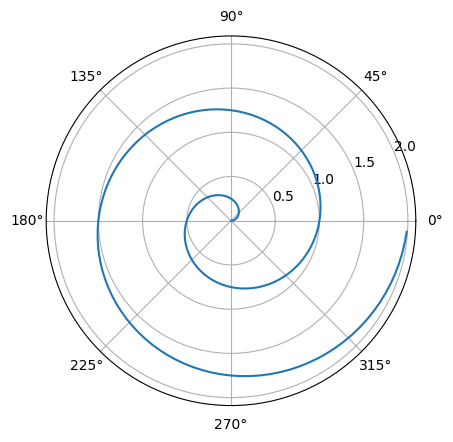

In [111]:
#| label: fig-polar
#| fig-cap: "A line plot on a polar axis"

import numpy as np
import matplotlib.pyplot as plt

r = np.arange(0, 2, 0.01)
theta = 2 * np.pi * r
fig, ax = plt.subplots(
    subplot_kw={'projection': 'polar'}
)
ax.plot(theta, r)
ax.set_rticks([0.5, 1, 1.5, 2])
ax.grid(True)
plt.show()

In [112]:
import pandas as pd

df = pd.DataFrame({
    'name': ['Alice', 'Bob'],
    'revenue': [1500.50, 2300.75],
    'growth': [0.152, 0.089]
})

# Rename columns and format
styled = (df
          .rename(columns={
    'revenue': 'Revenue ($)',
    'growth': 'YoY Growth'
})
          .style
          .format({'Revenue ($)': '${:,.2f}', 'YoY Growth': '{:.1%}'})
          .set_caption('Sales Summary')
          )

styled

,name,Revenue ($),YoY Growth
0,Alice,"$1,500.50",15.2%
1,Bob,"$2,300.75",8.9%


In [113]:
df

,name,revenue,growth
0,Alice,1500.50,0.152
1,Bob,2300.75,0.089
